# Relação entre as colunas do Abalone

1. Mapa de calor de correlação (colunas numéricas)
2. Matriz de dispersão (todas contra todas), colorida por `sex`
3. Relação de `sex` e `type` com as colunas numéricas
4. Relação entre `sex` e `type`

In [1]:
# Instale uma vez, se precisar: !pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
CAMINHO = "abalone_dataset.csv"  # troque pelo caminho do seu arquivo

df = pd.read_csv(CAMINHO)

colunas_categoricas = [c for c in ["sex", "type"] if c in df.columns]
colunas_numericas = [c for c in df.columns if c not in colunas_categoricas]
df.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type
0,M,0.535,0.420,0.150,0.6995,0.2575,0.1530,0.2400,3
1,I,0.510,0.380,0.115,0.5155,0.2150,0.1135,0.1660,1
2,I,0.185,0.130,0.045,0.0290,0.0120,0.0075,0.0095,1
3,M,0.550,0.450,0.170,0.8100,0.3170,0.1570,0.2200,3
4,I,0.535,0.415,0.150,0.5765,0.3595,0.1350,0.2250,1


## 1. Correlação entre as colunas numéricas

Valores perto de 1 indicam que as colunas crescem juntas; perto de 0, que não há relação linear.

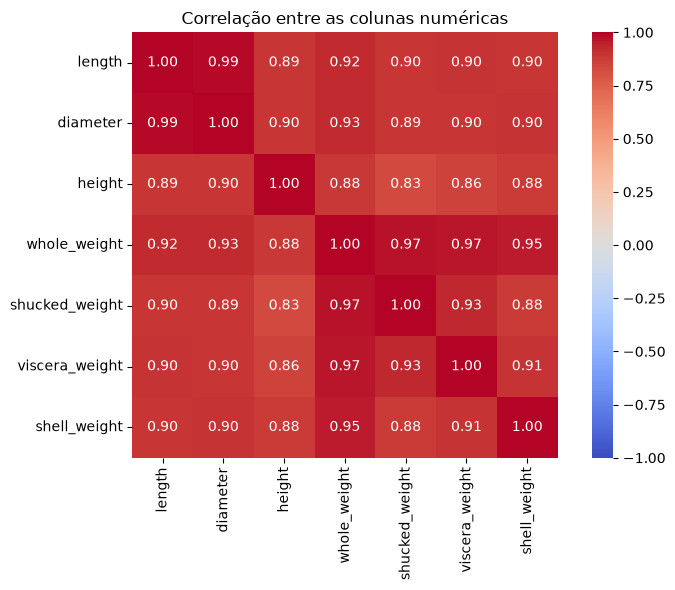

In [3]:
corr = df[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlação entre as colunas numéricas")
plt.tight_layout()
plt.show()

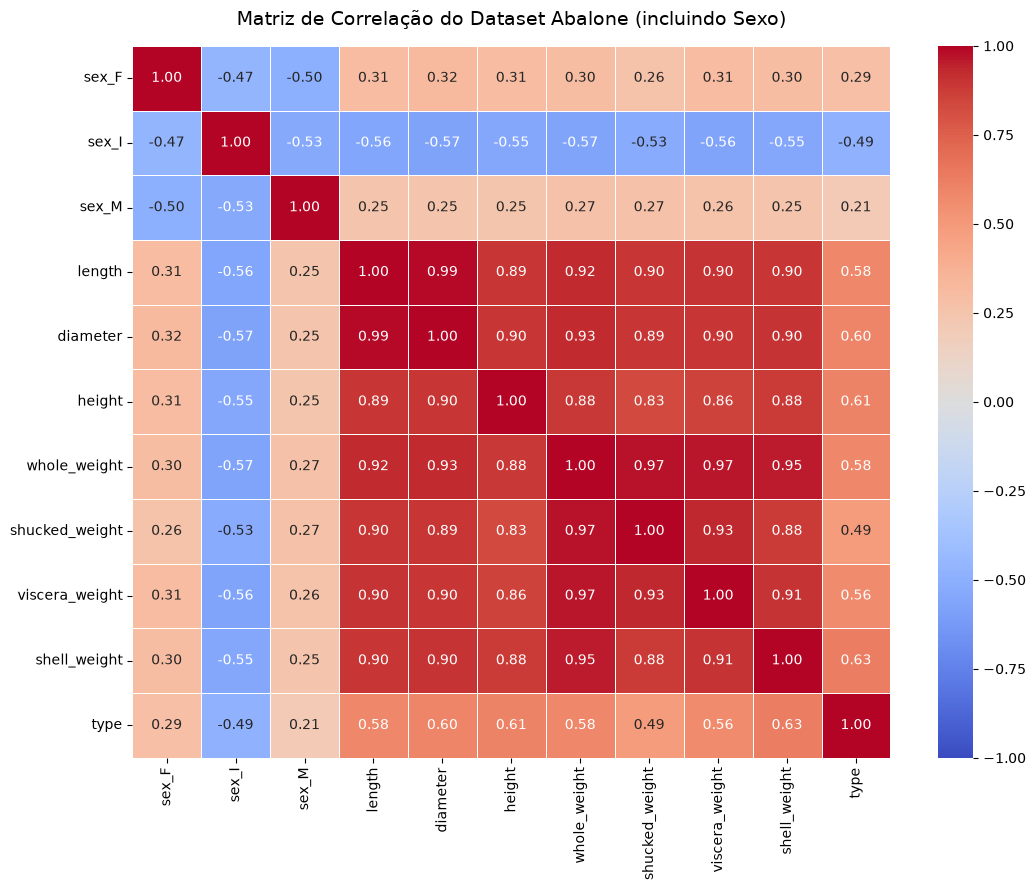

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o dataset
df = pd.read_csv('abalone_dataset.csv')

# 2. Converter a coluna 'sex' em colunas binárias numéricas (sex_F, sex_I, sex_M)
df_encoded = pd.get_dummies(df, columns=['sex'], drop_first=False)

# Reordenar as colunas para colocar as variáveis de sexo no início
cols = [c for c in df_encoded.columns if 'sex' in c] + [c for c in df_encoded.columns if 'sex' not in c]
df_encoded = df_encoded[cols]

# 3. Calcular a Matriz de Correlação
corr_matrix = df_encoded.corr()

# 4. Plotar o Heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

plt.title('Matriz de Correlação do Dataset Abalone (incluindo Sexo)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 2. Matriz de dispersão (cada coluna contra todas as outras)

A diagonal mostra a distribuição de cada coluna. Pode levar alguns segundos para carregar.

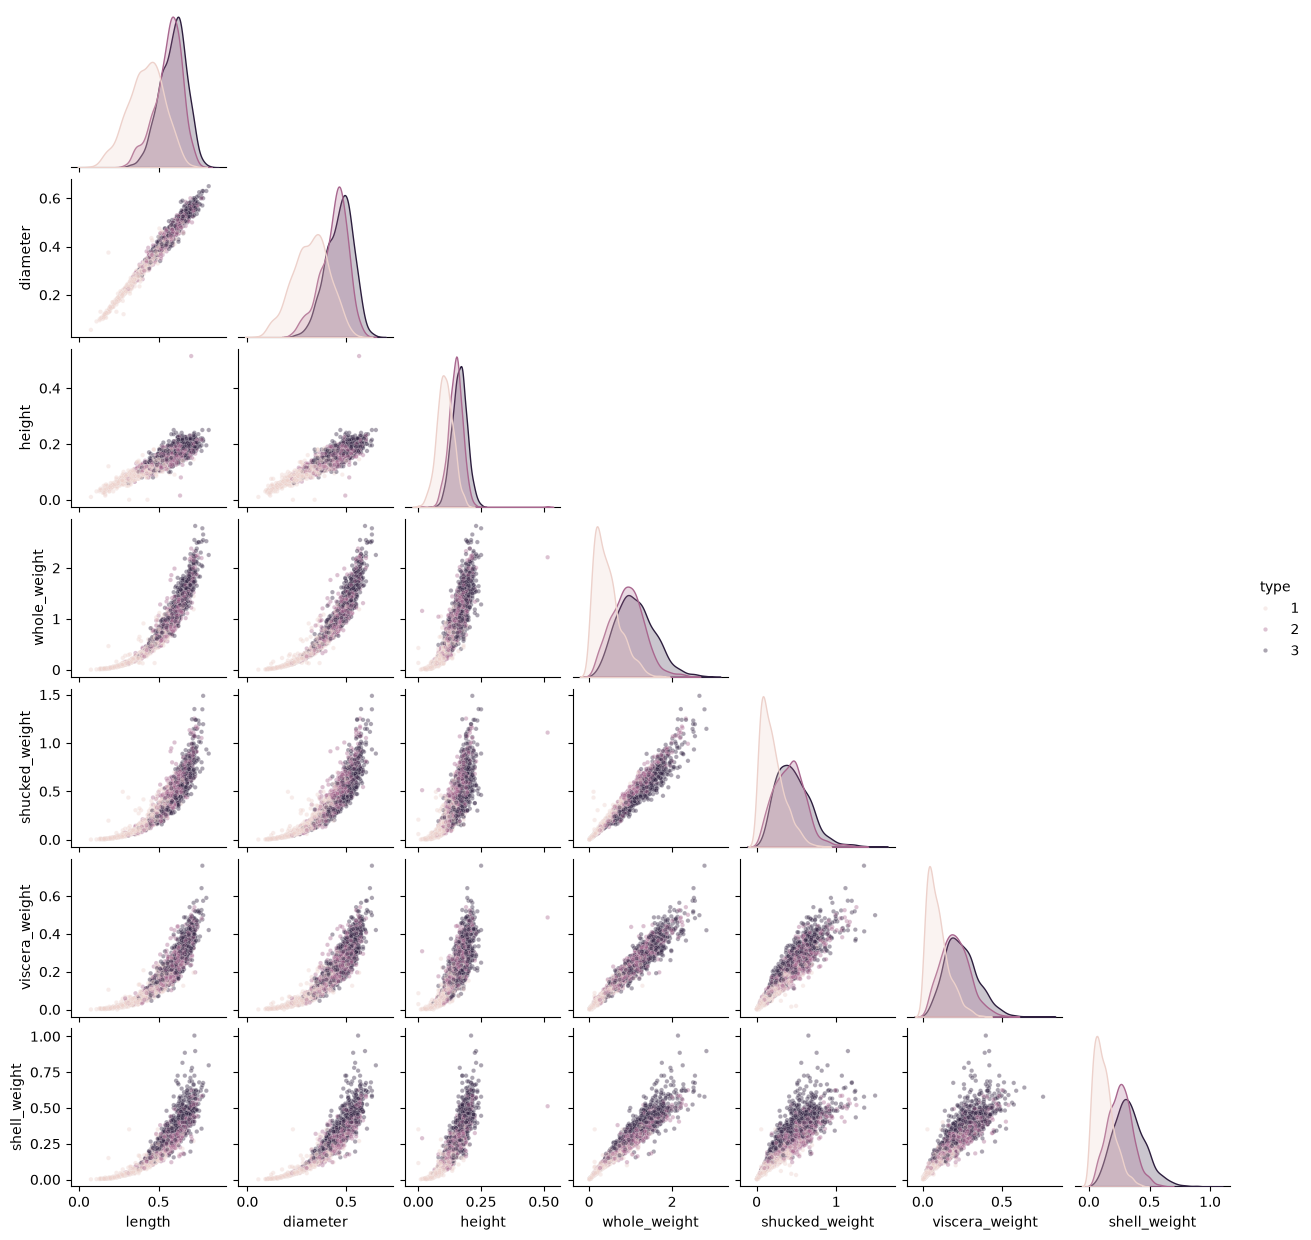

In [5]:
hue = "type" if "type" in df.columns else None

sns.pairplot(df, vars=colunas_numericas, hue=hue,
             corner=True, plot_kws={"alpha": 0.4, "s": 10}, height=1.8)
plt.show()

## 3. Colunas categóricas contra as numéricas

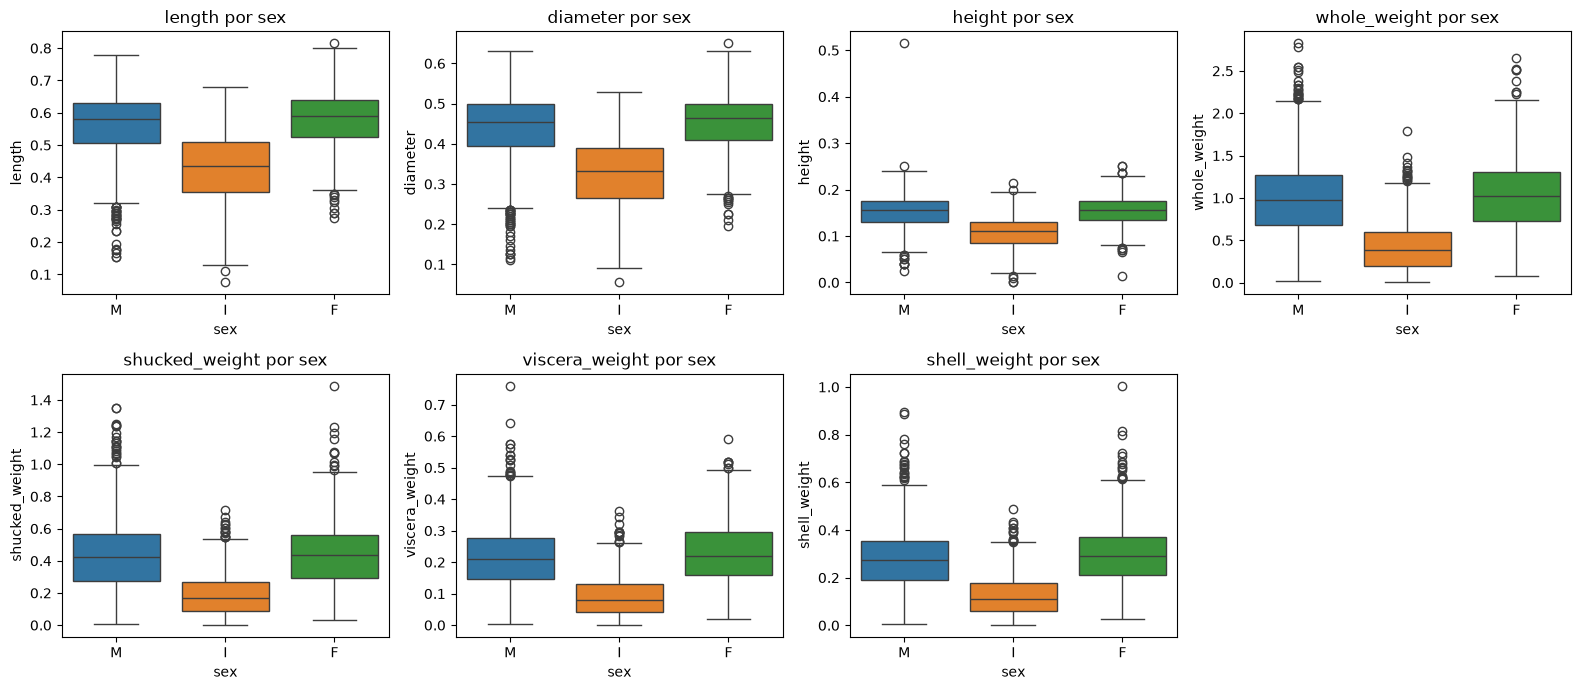

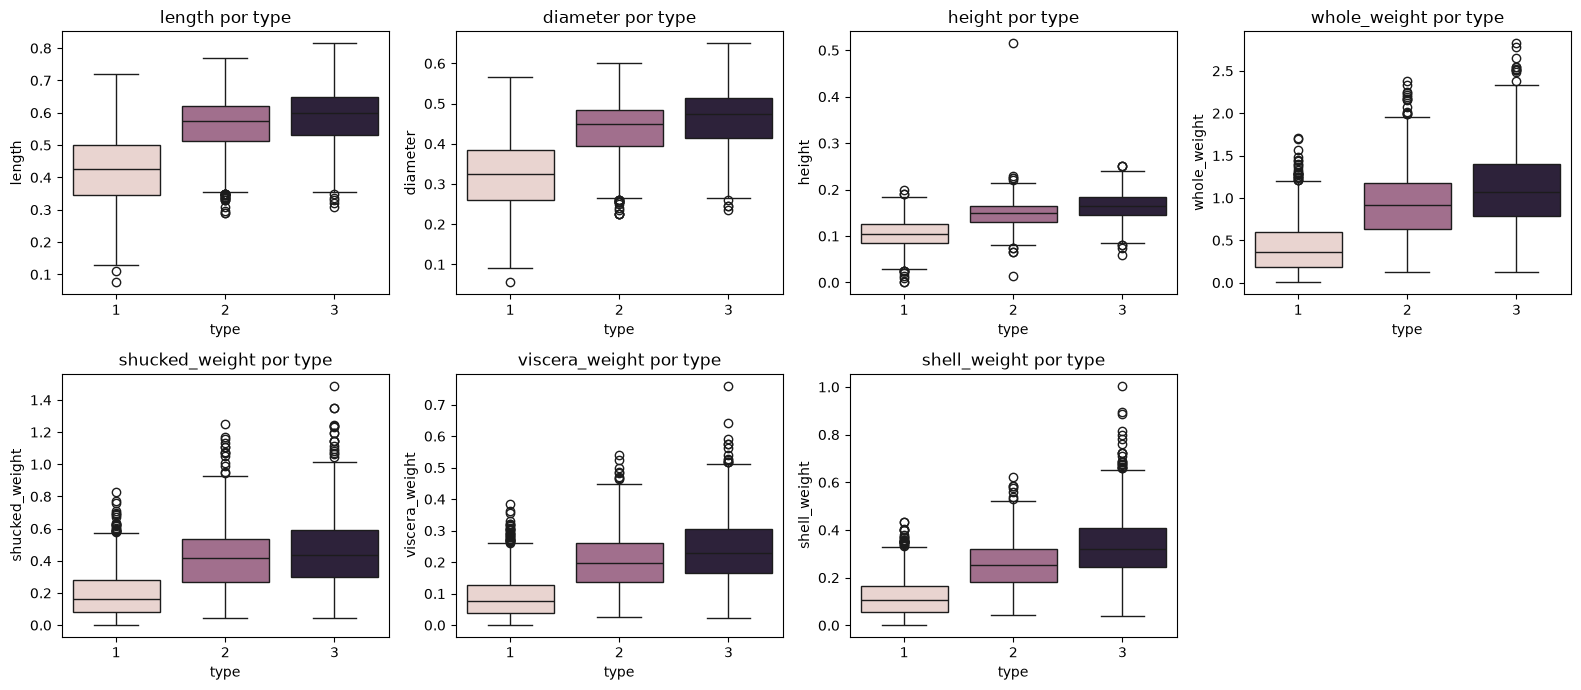

In [6]:
for cat in colunas_categoricas:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    for ax, col in zip(axes.ravel(), colunas_numericas):
        sns.boxplot(data=df, x=cat, y=col, ax=ax, hue=cat, legend=False)
        ax.set_title(f"{col} por {cat}")
    for ax in axes.ravel()[len(colunas_numericas):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 4. Relação entre `sex` e `type`

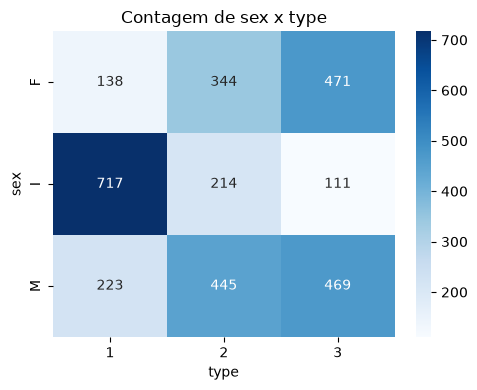

In [7]:
if len(colunas_categoricas) == 2:
    tabela = pd.crosstab(df["sex"], df["type"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(tabela, annot=True, fmt="d", cmap="Blues")
    plt.title("Contagem de sex x type")
    plt.tight_layout()
    plt.show()
else:
    print("O arquivo não tem as duas colunas categóricas (sex e type).")